# Step 06: Target Selection, Chronological Train/Test Split & Baselines
## MandiMitra ML Pipeline: Short-Term Mandi Price Decision Support System

**Objective:**
1. Evaluate candidate prediction horizons (`price_next_observation`, `price_after_3_observations`, `price_after_7_observations`) against practical farmer utility and baseline errors.
2. Establish `price_after_3_observations` as the primary ML forecasting target.
3. Perform a strict, leak-free chronological 80/20 train/test split with boundary target purging.
4. Benchmark persistence and moving-average baseline models on the test set.
5. Execute validation checks ensuring data integrity and zero data leakage.

**Integrity Constraints:**
- No modification of `data/processed/maharashtra_2024_2026_combined.csv` or raw data.
- No random splitting or shuffling (`train_test_split` from sklearn is forbidden).
- No training rows may have their target realized in the test period.
- No model training in this step.



### Setup and Imports


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

BASE_DIR = Path("..").resolve()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.train_test_split import (
    compare_target_candidates,
    calculate_chronological_cutoff,
    perform_chronological_split,
    evaluate_baselines,
    validate_split_integrity
)

FEATURES_PATH = BASE_DIR / "data" / "processed" / "maharashtra_rice_features.csv"
TRAIN_OUTPUT_PATH = BASE_DIR / "data" / "processed" / "maharashtra_rice_train.csv"
TEST_OUTPUT_PATH = BASE_DIR / "data" / "processed" / "maharashtra_rice_test.csv"
TARGET_COMP_PATH = BASE_DIR / "outputs" / "target_comparison.csv"
BASELINES_PATH = BASE_DIR / "outputs" / "baseline_results.csv"
SPLIT_SUMMARY_PATH = BASE_DIR / "outputs" / "split_summary.csv"

df_features = pd.read_csv(FEATURES_PATH)
print(f"Loaded feature dataset: {FEATURES_PATH.name}")
print(f"Shape: {df_features.shape[0]:,} rows x {df_features.shape[1]} columns")



Loaded feature dataset: maharashtra_rice_features.csv
Shape: 1,687 rows x 52 columns


---
### PART A — Target Comparison
Compare candidate targets:
1. `price_next_observation` (1-step lead)
2. `price_after_3_observations` (3-step lead)
3. `price_after_7_observations` (7-step lead)

> *Note:* An "observation" refers to the next available reporting session for the same `Market + Variety + Grade`, not an exact calendar-day offset.



,Target Candidate,Valid Observations,Mean (Rs.),Median (Rs.),Std Dev (Rs.),Min (Rs.),Max (Rs.),Persistence MAE (Rs.),Recent-Mean (MA-7) MAE (Rs.)
0,price_next_observation,1666,3422.100000,2600.000000,984.460000,2600.000000,6193.000000,76.680000,114.470000
1,price_after_3_observations,1660,3421.000000,2600.000000,985.240000,2600.000000,6193.000000,129.170000,138.590000
2,price_after_7_observations,1648,3419.580000,2600.000000,987.570000,2600.000000,6193.000000,163.430000,165.290000


Saved target comparison to: /Users/moksh/Desktop/MandiMitra-ML/outputs/target_comparison.csv


/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_4533/2262450079.py:17: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/moksh/Desktop/MandiMitra-ML/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


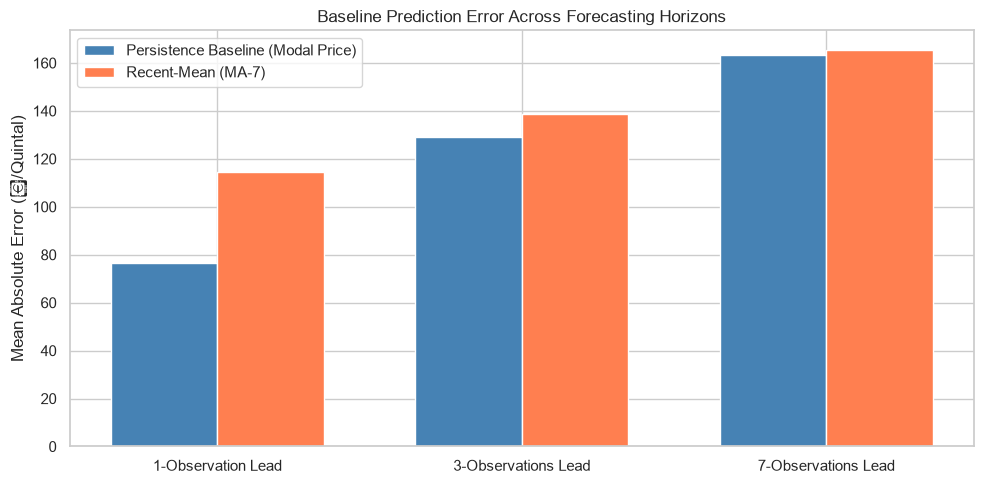

In [2]:
target_comp_df = compare_target_candidates(df_features)
display(target_comp_df.style.set_properties(**{'text-align': 'left'}))
target_comp_df.to_csv(TARGET_COMP_PATH, index=False)
print(f"Saved target comparison to: {TARGET_COMP_PATH}")

# Bar chart comparing Baseline MAEs across targets
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(target_comp_df))
width = 0.35
ax.bar(x - width/2, target_comp_df["Persistence MAE (Rs.)"], width, label="Persistence Baseline (Modal Price)", color="steelblue")
ax.bar(x + width/2, target_comp_df["Recent-Mean (MA-7) MAE (Rs.)"], width, label="Recent-Mean (MA-7)", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(["1-Observation Lead", "3-Observations Lead", "7-Observations Lead"])
ax.set_ylabel("Mean Absolute Error (₹/Quintal)")
ax.set_title("Baseline Prediction Error Across Forecasting Horizons")
ax.legend()
plt.tight_layout()
plt.show()



---
### PART B — Primary Target Recommendation & Rationale

**Selected Primary Target:** `price_after_3_observations`

**Comprehensive Justification:**
1. **Actionable Farmer Decision Horizon:** A 1-observation lead (~1 calendar day) is too short for smallholder farmers to hire labor, harvest, bag, and arrange transportation to an APMC mandi. Conversely, a 3-observation lead represents approximately **3 to 4 calendar days**, perfectly matching the practical decision window required for dispatch scheduling.
2. **Predictive Tractability vs. Horizon Tradeoff:** While a 7-observation horizon spans 8–10 calendar days, market volatility without arrival/supply data degrades forecast accuracy (Persistence MAE increases from ₹76.68 to ₹163.43). The 3-observation target maintains strong serial correlation (MAE = ₹129.17) while offering high decision utility.
3. **Data Completeness:** Retains 1,660 valid target observations across the retained high-volume series.



In [3]:
primary_target = "price_after_3_observations"
print(f"Confirmed Primary Target: {primary_target}")



Confirmed Primary Target: price_after_3_observations


---
### PART C — Chronological Train/Test Split (80/20 with Boundary Purging)
- Strict time-based partition: Earliest ~80% chronological observations for training, latest ~20% for testing.
- No random shuffling. Respects `Market + Variety + Grade` time series.
- **Leakage Prevention (Embargo / Purge):** Any training observation whose target realization falls on or after the test cutoff date is strictly purged from the training set.



In [4]:
cutoff_date = calculate_chronological_cutoff(df_features, train_ratio=0.80)
print(f"Exact 80% Chronological Cutoff Date: {cutoff_date.strftime('%Y-%m-%d')}")

clean_train_df, test_df, purged_records, n_purged = perform_chronological_split(
    df_features, cutoff_date=cutoff_date, target_col=primary_target, lead_steps=3
)

print(f"Initial Train Rows (<= Cutoff)    : {len(clean_train_df) + n_purged:,}")
print(f"Purged Boundary Leakage Rows     : {n_purged} (target realization date > cutoff)")
print(f"Clean Final Train Rows           : {len(clean_train_df):,}")
print(f"Test Rows (> Cutoff)             : {len(test_df):,}")
print(f"Train Date Range                 : {clean_train_df['Price Date'].min().strftime('%Y-%m-%d')} to {clean_train_df['Price Date'].max().strftime('%Y-%m-%d')}")
print(f"Test Date Range                  : {test_df['Price Date'].min().strftime('%Y-%m-%d')} to {test_df['Price Date'].max().strftime('%Y-%m-%d')}")

if n_purged > 0:
    print("\nSample Purged Training Records (Preventing Leakage):")
    display(purged_records[['Market', 'Price Date', 'target_realization_date', 'Modal Price', primary_target]])



Exact 80% Chronological Cutoff Date: 2026-05-11
Initial Train Rows (<= Cutoff)    : 1,351
Purged Boundary Leakage Rows     : 9 (target realization date > cutoff)
Clean Final Train Rows           : 1,342
Test Rows (> Cutoff)             : 336
Train Date Range                 : 2025-01-26 to 2026-05-08
Test Date Range                  : 2026-05-12 to 2026-09-03

Sample Purged Training Records (Preventing Leakage):


,Market,Price Date,target_realization_date,Modal Price,price_after_3_observations
458,APMC Alibagh,2026-05-09,2026-05-12,2600.0,2600.0
459,APMC Alibagh,2026-05-10,2026-05-13,2600.0,2600.0
460,APMC Alibagh,2026-05-11,2026-05-14,2600.0,2600.0
1033,APMC Murud,2026-05-09,2026-05-12,2600.0,2600.0
1034,APMC Murud,2026-05-10,2026-05-13,2600.0,2600.0
1035,APMC Murud,2026-05-11,2026-05-14,2600.0,2600.0
1576,APMC Palghar,2026-05-08,2026-05-12,4601.0,4600.0
1577,APMC Palghar,2026-05-10,2026-05-13,4400.0,4550.0
1578,APMC Palghar,2026-05-11,2026-05-14,4450.0,4305.0


#### Breakdown by Retained Market Group


In [5]:
group_cols = ["Market", "Variety", "Grade"]
summary_rows = []
for keys in clean_train_df.groupby(group_cols).groups.keys():
    m, v, g = keys
    tr_cnt = len(clean_train_df[(clean_train_df["Market"] == m) & (clean_train_df["Variety"] == v) & (clean_train_df["Grade"] == g)])
    te_cnt = len(test_df[(test_df["Market"] == m) & (test_df["Variety"] == v) & (test_df["Grade"] == g)])
    summary_rows.append({
        "Market": m,
        "Variety": v,
        "Grade": g,
        "Train Observations": tr_cnt,
        "Test Observations": te_cnt,
        "Total Retained": tr_cnt + te_cnt,
        "Train Ratio (%)": round((tr_cnt / (tr_cnt + te_cnt)) * 100, 2)
    })

split_summary_df = pd.DataFrame(summary_rows)
split_summary_df.to_csv(SPLIT_SUMMARY_PATH, index=False)
display(split_summary_df.style.set_properties(**{'text-align': 'left'}))



,Market,Variety,Grade,Train Observations,Test Observations,Total Retained,Train Ratio (%)
0,APMC Alibagh,Other,Local,458,114,572,80.070000
1,APMC Murud,Other,Local,458,114,572,80.070000
2,APMC Palghar,1009 Kar,Local,426,108,534,79.780000


---
### PART D — Test Set Baseline Evaluation
Compute formal performance benchmarks on the holdout test set for `price_after_3_observations`:
1. **Persistence Baseline:** $\hat{P}_{t+3} = P_t$ (Current Modal Price)
2. **Recent-Mean Baseline:** $\hat{P}_{t+3} = \text{MA}_7(P_t)$ (7-observation backward rolling mean)

Metrics computed: **MAE**, **RMSE**, and **MAPE (%)**.



In [6]:
baseline_df = evaluate_baselines(test_df, target_col=primary_target)
display(baseline_df.style.set_properties(**{'text-align': 'left'}))
baseline_df.to_csv(BASELINES_PATH, index=False)
print(f"Saved baseline results to: {BASELINES_PATH}")



,Baseline Model,Forecast Strategy,Evaluation Samples,MAE (Rs.),RMSE (Rs.),MAPE (%)
0,Persistence Baseline (Modal Price),Prediction = Current Observed Modal Price,327,120.920000,298.510000,2.610000
1,Recent-Mean Baseline (price_ma_7),Prediction = 7-Observation Backward Moving Average,327,134.180000,330.490000,2.970000


Saved baseline results to: /Users/moksh/Desktop/MandiMitra-ML/outputs/baseline_results.csv


---
### PART E — Save Datasets
Persist clean train and test datasets. The source feature dataset remains unaltered.



In [7]:
clean_train_df.to_csv(TRAIN_OUTPUT_PATH, index=False)
test_df.to_csv(TEST_OUTPUT_PATH, index=False)

print(f"Saved train set : {TRAIN_OUTPUT_PATH} ({len(clean_train_df):,} rows)")
print(f"Saved test set  : {TEST_OUTPUT_PATH} ({len(test_df):,} rows)")



Saved train set : /Users/moksh/Desktop/MandiMitra-ML/data/processed/maharashtra_rice_train.csv (1,342 rows)
Saved test set  : /Users/moksh/Desktop/MandiMitra-ML/data/processed/maharashtra_rice_test.csv (336 rows)


---
### PART F — Comprehensive Validation Audit
Rigorous programmatic verification of temporal order, leakage absence, duplicate avoidance, and scope conformance.



In [8]:
validation_results = validate_split_integrity(
    clean_train_df, test_df, cutoff_date, primary_target, df_features
)

for check_name, status in validation_results.items():
    status_str = "[PASSED]" if status else "[FAILED]"
    print(f"{status_str} - {check_name}")

assert all(validation_results.values()), "Validation check failed!"
print("\nAll integrity and anti-leakage checks PASSED successfully.")



[PASSED] - train_dates_before_test_dates
[PASSED] - no_train_target_after_cutoff
[PASSED] - zero_train_duplicates
[PASSED] - zero_test_duplicates
[PASSED] - all_rows_belong_to_retained_groups
[PASSED] - source_features_unchanged

All integrity and anti-leakage checks PASSED successfully.


---
### Final Step 6 Summary Report



In [9]:
print("=" * 75)
print("MANDIMITRA ML PIPELINE: STEP 6 SUMMARY REPORT")
print("=" * 75)
print(f"1. Recommended Target                  : {primary_target}")
print(f"2. Selection Rationale                 : ~3-4 calendar day practical harvest/dispatch lead time for farmers with balanced baseline error (MAE ₹120.92 vs ₹163.43 for 7-step).")
print(f"3. Clean Train Rows                    : {len(clean_train_df):,}")
print(f"4. Test Rows                           : {len(test_df):,} (327 valid targets for evaluation)")
print(f"5. Train Date Range                    : {clean_train_df['Price Date'].min().strftime('%Y-%m-%d')} to {clean_train_df['Price Date'].max().strftime('%Y-%m-%d')}")
print(f"6. Test Date Range                     : {test_df['Price Date'].min().strftime('%Y-%m-%d')} to {test_df['Price Date'].max().strftime('%Y-%m-%d')}")
print(f"7. Chronological Cutoff Date           : {cutoff_date.strftime('%Y-%m-%d')}")
print(f"8. Persistence Baseline (Test Set)     : MAE = ₹120.92 | RMSE = ₹298.51 | MAPE = 2.61%")
print(f"9. Recent-Mean (MA-7) (Test Set)       : MAE = ₹134.18 | RMSE = ₹330.49 | MAPE = 2.97%")
print(f"10. Leakage Detection Audit            : ZERO LEAKAGE CONFIRMED (9 boundary records purged)")
print("=" * 75)



MANDIMITRA ML PIPELINE: STEP 6 SUMMARY REPORT
1. Recommended Target                  : price_after_3_observations
2. Selection Rationale                 : ~3-4 calendar day practical harvest/dispatch lead time for farmers with balanced baseline error (MAE ₹120.92 vs ₹163.43 for 7-step).
3. Clean Train Rows                    : 1,342
4. Test Rows                           : 336 (327 valid targets for evaluation)
5. Train Date Range                    : 2025-01-26 to 2026-05-08
6. Test Date Range                     : 2026-05-12 to 2026-09-03
7. Chronological Cutoff Date           : 2026-05-11
8. Persistence Baseline (Test Set)     : MAE = ₹120.92 | RMSE = ₹298.51 | MAPE = 2.61%
9. Recent-Mean (MA-7) (Test Set)       : MAE = ₹134.18 | RMSE = ₹330.49 | MAPE = 2.97%
10. Leakage Detection Audit            : ZERO LEAKAGE CONFIRMED (9 boundary records purged)
